# Fase 4 — Métricas de cliente
**Asignatura:** Gestión de Datos — UAX  
**Alumno:** Álvaro González Fernández

Cálculo de tres KPIs por cliente sobre el DWH `saleshealth_dwh.db`:

1. **CLTV** (*Customer Lifetime Value*) — valor económico estimado del cliente
2. **Churn Risk** — clasificación según tiempo desde la última compra
3. **Return Rate** — proporción de devoluciones sobre compras

El Return Rate se calcula contra PostgreSQL (origen) porque la dimensión `return_item` queda fuera del scope del DWH (decidido en la Fase 2).

## 0. Setup — conexiones e imports

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# DWH (SQLite)
DWH_PATH = '../02_dwh/saleshealth_dwh.db'
dwh = sqlite3.connect(DWH_PATH)

# Origen (PostgreSQL) — necesario para return_item
PG_PARAMS = {
    'host': 'localhost', 'port': 5432, 'dbname': 'saleshealth',
    'user': 'postgres',  'password': 'alvaro',
}
pg_engine = create_engine(
    f"postgresql+psycopg2://{PG_PARAMS['user']}:{PG_PARAMS['password']}"
    f"@{PG_PARAMS['host']}:{PG_PARAMS['port']}/{PG_PARAMS['dbname']}"
)

# Estilo
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})
OUTPUT_DIR = '.'  # estamos ya dentro de 04_metricas/

print(f'✓ DWH: {DWH_PATH}')
print(f'✓ PG:  {PG_PARAMS["dbname"]}@{PG_PARAMS["host"]}')

✓ DWH: ../02_dwh/saleshealth_dwh.db
✓ PG:  saleshealth@localhost


## 1. Métrica 1 — CLTV (Customer Lifetime Value)

$$\mathrm{CLTV}_c = \mathrm{Ingresos}_c \times \mathrm{Margen}_c \times \mathrm{Frecuencia}_c \times R_c$$

donde:

- **Ingresos** = $\sum$ subtotal por cliente
- **Margen** = $\sum$ margin $\,/\,\sum$ subtotal (ratio)
- **Frecuencia** = nº de tickets distintos
- **R** = años de relación = $(\text{última} - \text{primera})/365.25 + 1$, mínimo 1

In [2]:
cltv_query = """
    SELECT
        f.customer_id,
        SUM(f.subtotal)                  AS ingresos,
        SUM(f.margin)                    AS margen_total,
        COUNT(DISTINCT f.sale_id)        AS frecuencia,
        MIN(d.date)                      AS primera_compra,
        MAX(d.date)                      AS ultima_compra
    FROM   fact_sales f
    JOIN   dim_date  d ON f.date_id = d.date_id
    GROUP BY f.customer_id
"""
df_cltv = pd.read_sql(cltv_query, dwh)

# Conversión de fechas y cálculo de años de relación
df_cltv['primera_compra'] = pd.to_datetime(df_cltv['primera_compra'])
df_cltv['ultima_compra']  = pd.to_datetime(df_cltv['ultima_compra'])
df_cltv['anios_relacion'] = (
    (df_cltv['ultima_compra'] - df_cltv['primera_compra']).dt.days / 365.25 + 1
).clip(lower=1.0)

# Margen relativo (ratio) — protegemos división por cero
df_cltv['margen_ratio'] = np.where(
    df_cltv['ingresos'] > 0,
    df_cltv['margen_total'] / df_cltv['ingresos'],
    0.0,
)

# Fórmula final
df_cltv['cltv'] = (
    df_cltv['ingresos']
    * df_cltv['margen_ratio']
    * df_cltv['frecuencia']
    * df_cltv['anios_relacion']
)

print(f'Clientes con al menos una compra: {len(df_cltv):,}')
df_cltv.head()

Clientes con al menos una compra: 5,750


,customer_id,ingresos,margen_total,frecuencia,primera_compra,ultima_compra,anios_relacion,margen_ratio,cltv
0,1,11732.55,4688.48,22,2020-06-29,2025-10-01,6.256674,0.399613,6.453543e+05
1,2,12744.26,5098.08,24,2020-03-02,2025-10-30,6.661875,0.400030,8.151066e+05
2,3,19862.51,7957.43,24,2020-08-17,2025-11-07,6.223819,0.400626,1.188615e+06
3,4,8203.76,3317.69,10,2020-04-19,2025-12-12,6.648186,0.404411,2.205662e+05
4,5,10938.05,4411.45,22,2020-03-17,2025-12-07,6.724846,0.403312,6.526591e+05


### 1.1 Estadísticas descriptivas

In [3]:
stats_cols = ['ingresos', 'margen_ratio', 'frecuencia', 'anios_relacion', 'cltv']
summary_cltv = df_cltv[stats_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2)
display(summary_cltv)

,ingresos,margen_ratio,frecuencia,anios_relacion,cltv
count,5750.00,5750.00,5750.00,5750.00,5750.00
mean,1683.25,0.40,3.48,1.70,83352.91
std,4089.97,0.02,6.59,1.82,241742.43
min,19.99,0.40,1.00,1.00,8.00
25%,79.80,0.40,1.00,1.00,31.92
50%,149.90,0.40,1.00,1.00,59.96
75%,299.99,0.40,1.00,1.00,120.00
90%,9466.41,0.40,17.00,6.13,401146.23
99%,16396.11,0.41,26.00,6.85,1095034.82
max,24922.00,1.00,34.00,6.98,2240278.36


### 1.2 Visualización — distribución del CLTV

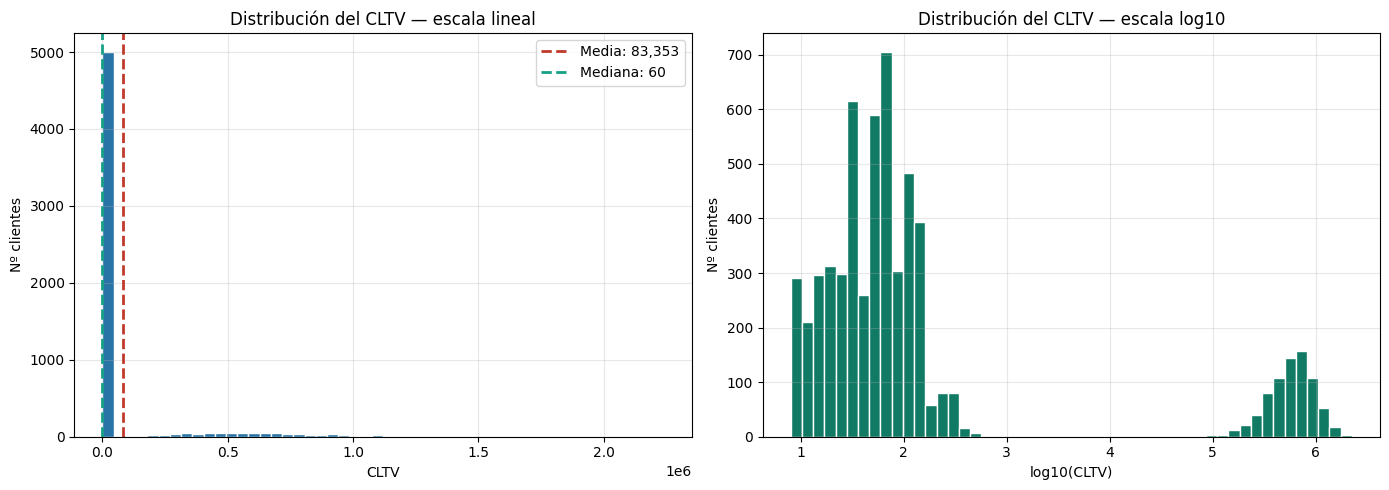

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma escala lineal
axes[0].hist(df_cltv['cltv'], bins=50, color='#2874a6', edgecolor='white')
axes[0].axvline(df_cltv['cltv'].mean(),   color='#c0392b', ls='--', lw=2, label=f"Media: {df_cltv['cltv'].mean():,.0f}")
axes[0].axvline(df_cltv['cltv'].median(), color='#16a085', ls='--', lw=2, label=f"Mediana: {df_cltv['cltv'].median():,.0f}")
axes[0].set_title('Distribución del CLTV — escala lineal')
axes[0].set_xlabel('CLTV')
axes[0].set_ylabel('Nº clientes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma escala log (la cola larga aplasta el eje lineal)
positive = df_cltv['cltv'][df_cltv['cltv'] > 0]
axes[1].hist(np.log10(positive), bins=50, color='#117a65', edgecolor='white')
axes[1].set_title('Distribución del CLTV — escala log10')
axes[1].set_xlabel('log10(CLTV)')
axes[1].set_ylabel('Nº clientes')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cltv_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Top 10 clientes por CLTV

In [5]:
# Enriquecemos con nombre del cliente
df_cust = pd.read_sql('SELECT customer_id, first_name, last_name FROM dim_customer;', dwh)

top10 = (
    df_cltv.merge(df_cust, on='customer_id', how='left')
           .sort_values('cltv', ascending=False)
           .head(10)
           [['customer_id', 'first_name', 'last_name',
             'ingresos', 'margen_ratio', 'frecuencia', 'anios_relacion', 'cltv']]
           .round(2)
           .reset_index(drop=True)
)
display(top10)

# Guardar Top-10 también
top10.to_csv(os.path.join(OUTPUT_DIR, 'cltv_top10.csv'), index=False, encoding='utf-8')
df_cltv.to_csv(os.path.join(OUTPUT_DIR, 'cltv.csv'),     index=False, encoding='utf-8')
print('✓ Guardados: cltv.csv  ·  cltv_top10.csv')

,customer_id,first_name,last_name,ingresos,margen_ratio,frecuencia,anios_relacion,cltv
0,183,Alejandro,Pérez,24922.00,0.4,33,6.79,2240278.36
1,212,Sergio,Álvarez,21281.51,0.4,34,6.54,1893376.58
2,228,Carlos,García,22268.34,0.4,30,6.94,1855647.57
3,456,David,Díaz,21566.04,0.4,31,6.38,1708237.37
4,750,Laura,García,19911.40,0.4,31,6.75,1685476.79
5,500,Sergio,Martínez,19215.39,0.4,32,6.56,1614889.08
6,343,Alejandro,Fernández,21167.80,0.4,30,6.33,1611300.23
7,306,Carlos,Pérez,19816.97,0.4,28,6.96,1554877.81
8,214,Javier,Ruiz,19872.08,0.4,29,6.59,1526221.22
9,163,Ana,Martínez,18357.35,0.4,31,6.67,1525218.11


✓ Guardados: cltv.csv  ·  cltv_top10.csv


## 2. Métrica 2 — Churn Risk

Clasificación según el tiempo transcurrido desde la última compra. La fecha de referencia es la **última fecha registrada en el DWH** (no `today()`), para mantener el análisis reproducible y consistente con el dataset.

| Estado | Días desde última compra |
|---|---|
| Activo | < 180 |
| En riesgo | 180–365 |
| Perdido | > 365 |

In [6]:
# Fecha de referencia: máxima en fact_sales
ref_date = pd.read_sql(
    'SELECT MAX(d.date) AS ref FROM fact_sales f JOIN dim_date d ON f.date_id = d.date_id;',
    dwh,
).loc[0, 'ref']
ref_date = pd.to_datetime(ref_date)
print(f'Fecha de referencia: {ref_date.date()}')

df_churn = df_cltv[['customer_id', 'ultima_compra']].copy()
df_churn['dias_ultima_compra'] = (ref_date - df_churn['ultima_compra']).dt.days

def classify_churn(d):
    if d < 180:
        return 'Activo'
    elif d <= 365:
        return 'En riesgo'
    return 'Perdido'

df_churn['estado_churn'] = df_churn['dias_ultima_compra'].apply(classify_churn)
df_churn.head()

Fecha de referencia: 2025-12-30


,customer_id,ultima_compra,dias_ultima_compra,estado_churn
0,1,2025-10-01,90,Activo
1,2,2025-10-30,61,Activo
2,3,2025-11-07,53,Activo
3,4,2025-12-12,18,Activo
4,5,2025-12-07,23,Activo


### 2.1 Estadísticas descriptivas

In [7]:
summary_churn = df_churn['dias_ultima_compra'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
).round(1)
print('Días desde la última compra:')
display(summary_churn)

counts = df_churn['estado_churn'].value_counts().reindex(['Activo', 'En riesgo', 'Perdido'])
pct    = (counts / counts.sum() * 100).round(1)
df_churn_summary = pd.DataFrame({'clientes': counts, '%': pct})
display(df_churn_summary)

Días desde la última compra:


count    5750.0
mean      673.5
std       601.1
min         0.0
25%        92.0
50%       421.0
75%      1299.8
90%      1457.0
max      1824.0
Name: dias_ultima_compra, dtype: float64

,clientes,%
estado_churn,,
Activo,2069,36.0
En riesgo,141,2.5
Perdido,3540,61.6


### 2.2 Visualización

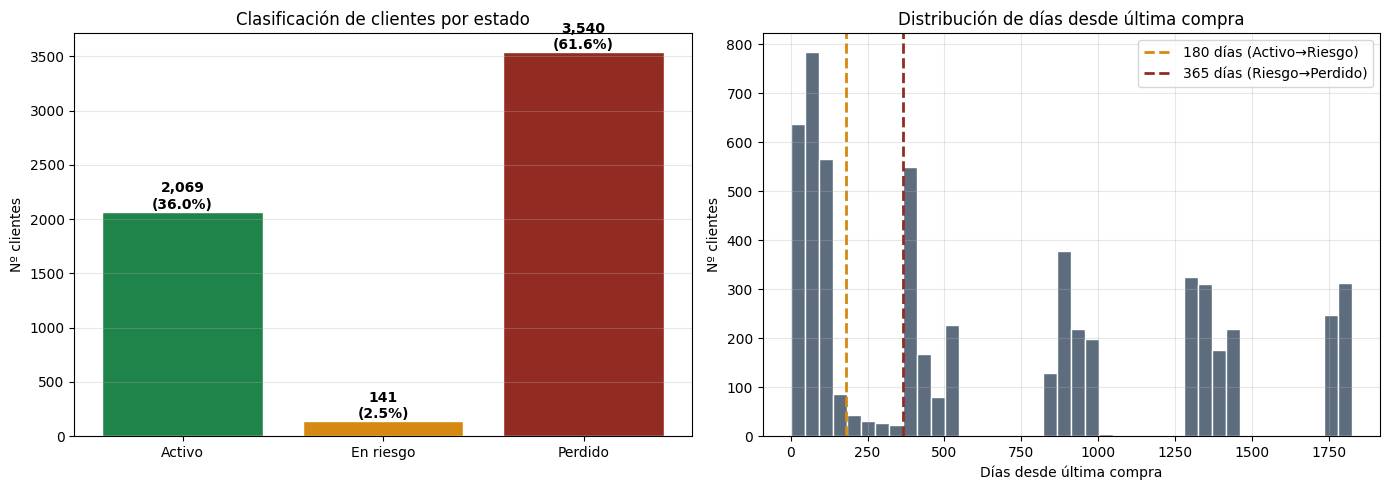

✓ Guardado: churn.csv


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por estado
color_map = {'Activo': '#1e8449', 'En riesgo': '#d68910', 'Perdido': '#922b21'}
bars = axes[0].bar(
    counts.index, counts.values,
    color=[color_map[c] for c in counts.index], edgecolor='white',
)
axes[0].set_title('Clasificación de clientes por estado')
axes[0].set_ylabel('Nº clientes')
for b, v, p in zip(bars, counts.values, pct.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'{v:,}\n({p}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histograma de días
axes[1].hist(df_churn['dias_ultima_compra'], bins=40, color='#5d6d7e', edgecolor='white')
axes[1].axvline(180, color='#d68910', ls='--', lw=2, label='180 días (Activo→Riesgo)')
axes[1].axvline(365, color='#922b21', ls='--', lw=2, label='365 días (Riesgo→Perdido)')
axes[1].set_title('Distribución de días desde última compra')
axes[1].set_xlabel('Días desde última compra')
axes[1].set_ylabel('Nº clientes')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('churn_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

df_churn.to_csv(os.path.join(OUTPUT_DIR, 'churn.csv'), index=False, encoding='utf-8')
print('✓ Guardado: churn.csv')

## 3. Métrica 3 — Return Rate

$$\mathrm{ReturnRate}_c = \frac{\#\,\text{items devueltos}_c}{\#\,\text{items comprados}_c}$$

Calculado contra **PostgreSQL** porque `return_item` no se materializó en el DWH (la fase 2 acotó el alcance al subject area de ventas).

In [9]:
return_query = """
    WITH purchases AS (
        SELECT s.customer_id, COUNT(*) AS items_comprados
        FROM   sale_item si
        JOIN   sale s ON si.sale_id = s.sale_id
        GROUP  BY s.customer_id
    ),
    returns AS (
        SELECT s.customer_id, COUNT(*) AS items_devueltos
        FROM   return_item ri
        JOIN   sale_item si ON ri.sale_item_id = si.sale_item_id
        JOIN   sale s       ON si.sale_id     = s.sale_id
        GROUP  BY s.customer_id
    )
    SELECT  p.customer_id,
            p.items_comprados,
            COALESCE(r.items_devueltos, 0) AS items_devueltos,
            CASE WHEN p.items_comprados > 0
                 THEN COALESCE(r.items_devueltos, 0)::float / p.items_comprados
                 ELSE 0 END AS return_rate
    FROM       purchases p
    LEFT JOIN  returns   r USING (customer_id)
    ORDER BY   p.customer_id;
"""
df_return = pd.read_sql(return_query, pg_engine)

print(f'Clientes con compras: {len(df_return):,}')
print(f'Clientes con al menos una devolución: {(df_return["items_devueltos"] > 0).sum():,}')
df_return.head()

Clientes con compras: 5,750
Clientes con al menos una devolución: 1,124


,customer_id,items_comprados,items_devueltos,return_rate
0,1,57,2,0.035088
1,2,64,6,0.093750
2,3,72,5,0.069444
3,4,28,2,0.071429
4,5,54,4,0.074074


> **Nota sobre `Return Rate > 1`.** En las estadísticas siguientes verás que el percentil 99 y el máximo del Return Rate alcanzan valores **mayores que 1**. Hay aproximadamente **440 clientes** en esa situación, lo que significa que han devuelto más artículos de los que aparecen comprados en el dataset.
>
> Esto ocurre porque el dataset de ventas cubre un periodo concreto, pero las devoluciones pueden corresponder a compras **anteriores a ese periodo** que no están registradas en `sale_item`. **No es un error de datos**, sino una limitación del alcance temporal del dataset. Estos clientes se identifican como un cluster propio en la Fase 5 (cluster *Devolutivo*) precisamente porque su patrón es estructuralmente distinto al del resto.

### 3.1 Estadísticas descriptivas

In [10]:
summary_return = df_return[['items_comprados', 'items_devueltos', 'return_rate']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]
).round(3)
display(summary_return)

,items_comprados,items_devueltos,return_rate
count,5750.000,5750.000,5750.000
mean,7.401,0.405,0.086
std,17.090,1.039,0.281
min,1.000,0.000,0.000
25%,1.000,0.000,0.000
50%,1.000,0.000,0.000
75%,1.000,0.000,0.000
90%,41.000,1.000,0.077
99%,67.000,5.000,1.000
max,97.000,8.000,2.000


### 3.2 Visualización

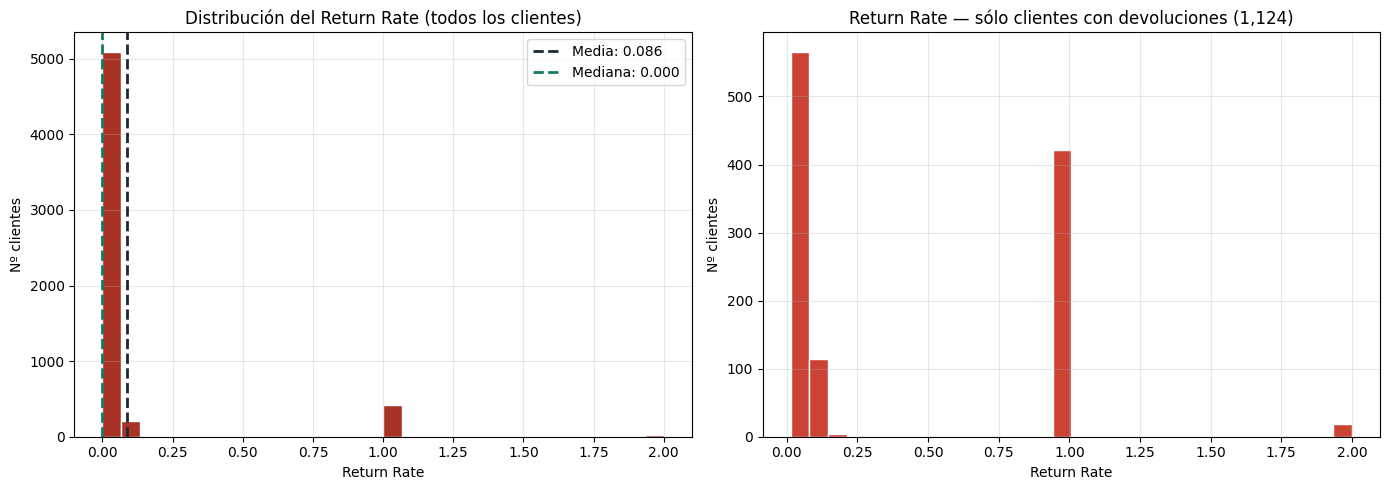

✓ Guardado: return_rate.csv


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del return_rate (todos los clientes)
axes[0].hist(df_return['return_rate'], bins=30, color='#a93226', edgecolor='white')
axes[0].axvline(df_return['return_rate'].mean(),   color='#1c2833', ls='--', lw=2,
                label=f"Media: {df_return['return_rate'].mean():.3f}")
axes[0].axvline(df_return['return_rate'].median(), color='#117a65', ls='--', lw=2,
                label=f"Mediana: {df_return['return_rate'].median():.3f}")
axes[0].set_title('Distribución del Return Rate (todos los clientes)')
axes[0].set_xlabel('Return Rate')
axes[0].set_ylabel('Nº clientes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma sólo de clientes con devoluciones (>0)
with_returns = df_return[df_return['return_rate'] > 0]['return_rate']
axes[1].hist(with_returns, bins=30, color='#cb4335', edgecolor='white')
axes[1].set_title(f'Return Rate — sólo clientes con devoluciones ({len(with_returns):,})')
axes[1].set_xlabel('Return Rate')
axes[1].set_ylabel('Nº clientes')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('return_rate_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

df_return.to_csv(os.path.join(OUTPUT_DIR, 'return_rate.csv'), index=False, encoding='utf-8')
print('✓ Guardado: return_rate.csv')

## 4. DataFrame consolidado — `df_clientes_final`

Combina las 3 métricas en un único registro por cliente.

In [12]:
df_clientes_final = (
    df_cltv[['customer_id', 'ingresos', 'margen_ratio', 'frecuencia',
             'anios_relacion', 'cltv']]
    .merge(df_churn[['customer_id', 'dias_ultima_compra', 'estado_churn']],
           on='customer_id', how='outer')
    .merge(df_return[['customer_id', 'items_comprados', 'items_devueltos', 'return_rate']],
           on='customer_id', how='outer')
    .sort_values('cltv', ascending=False)
    .reset_index(drop=True)
)

# Redondeos para presentación
for c, decimals in [('ingresos', 2), ('margen_ratio', 4), ('anios_relacion', 2),
                     ('cltv', 2), ('return_rate', 4)]:
    df_clientes_final[c] = df_clientes_final[c].round(decimals)

print(f'Clientes en el DataFrame final: {len(df_clientes_final):,}')
print(f'Columnas: {list(df_clientes_final.columns)}')
df_clientes_final.head(15)

Clientes en el DataFrame final: 5,750
Columnas: ['customer_id', 'ingresos', 'margen_ratio', 'frecuencia', 'anios_relacion', 'cltv', 'dias_ultima_compra', 'estado_churn', 'items_comprados', 'items_devueltos', 'return_rate']


,customer_id,ingresos,margen_ratio,frecuencia,anios_relacion,cltv,dias_ultima_compra,estado_churn,items_comprados,items_devueltos,return_rate
0,183,24922.00,0.4015,33,6.79,2240278.36,73,Activo,97,6,0.0619
1,212,21281.51,0.4000,34,6.54,1893376.58,147,Activo,86,2,0.0233
2,228,22268.34,0.4000,30,6.94,1855647.57,8,Activo,81,2,0.0247
3,456,21566.04,0.4003,31,6.38,1708237.37,157,Activo,83,5,0.0602
4,750,19911.40,0.4042,31,6.75,1685476.79,38,Activo,87,6,0.0690
5,500,19215.39,0.4006,32,6.56,1614889.08,72,Activo,82,2,0.0244
6,343,21167.80,0.4012,30,6.33,1611300.23,46,Activo,86,4,0.0465
7,306,19816.97,0.4024,28,6.96,1554877.81,12,Activo,71,6,0.0845
8,214,19872.08,0.4018,29,6.59,1526221.22,8,Activo,79,6,0.0759
9,163,18357.35,0.4020,31,6.67,1525218.11,35,Activo,79,3,0.0380


In [13]:
# Vista global por estado de churn
pivot = (
    df_clientes_final.groupby('estado_churn').agg(
        n_clientes      = ('customer_id', 'count'),
        cltv_medio      = ('cltv',         'mean'),
        cltv_mediano    = ('cltv',         'median'),
        return_rate_med = ('return_rate',  'mean'),
    ).round(2)
    .reindex(['Activo', 'En riesgo', 'Perdido'])
)
print('CLTV y Return Rate medios según estado de churn:')
display(pivot)

# Guardar el DataFrame consolidado
df_clientes_final.to_csv(os.path.join(OUTPUT_DIR, 'clientes_final.csv'),
                          index=False, encoding='utf-8')
print('✓ Guardado: clientes_final.csv  (DataFrame consolidado de la Fase 4)')

CLTV y Return Rate medios según estado de churn:


,n_clientes,cltv_medio,cltv_mediano,return_rate_med
estado_churn,,,,
Activo,2069,192751.27,72.00,0.08
En riesgo,141,487804.86,448831.66,0.05
Perdido,3540,3304.05,51.96,0.09


✓ Guardado: clientes_final.csv  (DataFrame consolidado de la Fase 4)


## 5. Cierre de conexiones

In [14]:
dwh.close()
pg_engine.dispose()
print('✓ Conexiones cerradas. Métricas listas para la Fase 5 (PCA + Clustering).')

✓ Conexiones cerradas. Métricas listas para la Fase 5 (PCA + Clustering).
